TimeSeries

In [26]:
import pandas as pd
import numpy as np
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [11]:
df = pd.read_csv("../data/daily-total-female-births.csv")
df.head(10)

,Date,Births
0,1959-01-01,35
1,1959-01-02,32
2,1959-01-03,30
3,1959-01-04,31
4,1959-01-05,44
5,1959-01-06,29
6,1959-01-07,45
7,1959-01-08,43
8,1959-01-09,38
9,1959-01-10,27


In [12]:
df.dtypes

Date        str
Births    int64
dtype: object

Feature Engineering

1- Moving Average

In [ ]:
windows = [3,5,10,15]
for window in windows:
    df[f"Birth W{window}"] = df['Births'].rolling(window=window).mean()

df.head()

,Date,Births,Birth W3,Birth W5,Birth W10,Birth W15
0,1959-01-01,35,NaN,NaN,NaN,NaN
1,1959-01-02,32,NaN,NaN,NaN,NaN
2,1959-01-03,30,32.333333,NaN,NaN,NaN
3,1959-01-04,31,31.000000,NaN,NaN,NaN
4,1959-01-05,44,35.000000,34.4,NaN,NaN


In [14]:
df.head(20)

,Date,Births,Birth W3,Birth W5,Birth W10,Birth W15
0,1959-01-01,35,NaN,NaN,NaN,NaN
1,1959-01-02,32,NaN,NaN,NaN,NaN
2,1959-01-03,30,32.333333,NaN,NaN,NaN
3,1959-01-04,31,31.000000,NaN,NaN,NaN
4,1959-01-05,44,35.000000,34.4,NaN,NaN
5,1959-01-06,29,34.666667,33.2,NaN,NaN
6,1959-01-07,45,39.333333,35.8,NaN,NaN
7,1959-01-08,43,39.000000,38.4,NaN,NaN
8,1959-01-09,38,42.000000,39.8,NaN,NaN
9,1959-01-10,27,36.000000,36.4,35.4,NaN


<Axes: title={'center': 'Daily Total Female Births in California'}, xlabel='Date'>

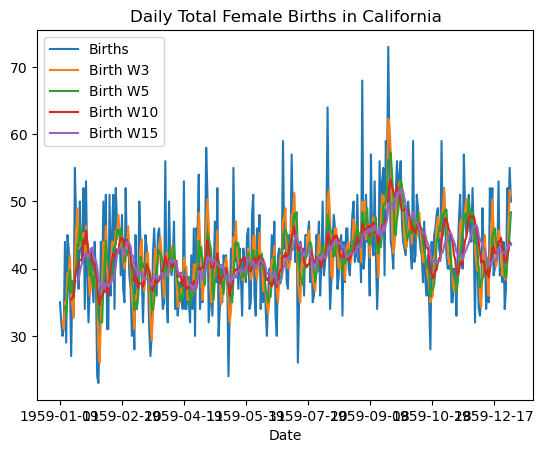

In [15]:
#plotting the data
df.plot(x='Date', y=['Births', 'Birth W3', 'Birth W5', 'Birth W10', 'Birth W15'], title='Daily Total Female Births in California')

In [16]:
fig = px.line(df, x='Date', y=['Births', 'Birth W3', 'Birth W5', 'Birth W10', 'Birth W15'], 
title='Daily Total Female Births in California')
fig.show()

2- Lagging

In [17]:
df['Day -1'] = df['Births'].shift(1)
df['Day -2'] = df['Births'].shift(2)

#lagging with diffence
df['Diff -1'] = df['Births'].diff(1)

#lagging with ratio
df['Ratio -1'] = df['Diff -1'] / df['Day -1']

df.head()

,Date,Births,Birth W3,Birth W5,Birth W10,Birth W15,Day -1,Day -2,Diff -1,Ratio -1
0,1959-01-01,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1959-01-02,32,NaN,NaN,NaN,NaN,35.0,NaN,-3.0,-0.085714
2,1959-01-03,30,32.333333,NaN,NaN,NaN,32.0,35.0,-2.0,-0.062500
3,1959-01-04,31,31.000000,NaN,NaN,NaN,30.0,32.0,1.0,0.033333
4,1959-01-05,44,35.000000,34.4,NaN,NaN,31.0,30.0,13.0,0.419355


In [18]:
df.head(20)

,Date,Births,Birth W3,Birth W5,Birth W10,Birth W15,Day -1,Day -2,Diff -1,Ratio -1
0,1959-01-01,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1959-01-02,32,NaN,NaN,NaN,NaN,35.0,NaN,-3.0,-0.085714
2,1959-01-03,30,32.333333,NaN,NaN,NaN,32.0,35.0,-2.0,-0.062500
3,1959-01-04,31,31.000000,NaN,NaN,NaN,30.0,32.0,1.0,0.033333
4,1959-01-05,44,35.000000,34.4,NaN,NaN,31.0,30.0,13.0,0.419355
5,1959-01-06,29,34.666667,33.2,NaN,NaN,44.0,31.0,-15.0,-0.340909
6,1959-01-07,45,39.333333,35.8,NaN,NaN,29.0,44.0,16.0,0.551724
7,1959-01-08,43,39.000000,38.4,NaN,NaN,45.0,29.0,-2.0,-0.044444
8,1959-01-09,38,42.000000,39.8,NaN,NaN,43.0,45.0,-5.0,-0.116279
9,1959-01-10,27,36.000000,36.4,35.4,NaN,38.0,43.0,-11.0,-0.289474


In [19]:
df.dropna(inplace=True)
df.head(20)

,Date,Births,Birth W3,Birth W5,Birth W10,Birth W15,Day -1,Day -2,Diff -1,Ratio -1
14,1959-01-15,45,49.000000,43.6,40.0,38.133333,47.0,55.0,-2.0,-0.042553
15,1959-01-16,37,43.000000,43.4,40.8,38.266667,45.0,47.0,-8.0,-0.177778
16,1959-01-17,50,44.000000,46.8,41.3,39.466667,37.0,45.0,13.0,0.351351
17,1959-01-18,43,43.333333,44.4,41.3,40.333333,50.0,37.0,-7.0,-0.140000
18,1959-01-19,41,44.666667,43.2,41.6,41.000000,43.0,50.0,-2.0,-0.046512
19,1959-01-20,52,45.333333,44.6,44.1,41.533333,41.0,43.0,11.0,0.268293
20,1959-01-21,34,42.333333,44.0,43.7,41.866667,52.0,41.0,-18.0,-0.346154
21,1959-01-22,53,46.333333,44.6,45.7,42.400000,34.0,52.0,19.0,0.558824
22,1959-01-23,39,42.000000,43.8,44.1,42.133333,53.0,34.0,-14.0,-0.264151
23,1959-01-24,32,41.333333,42.0,42.6,41.733333,39.0,53.0,-7.0,-0.179487


In [20]:
df.dtypes

Date             str
Births         int64
Birth W3     float64
Birth W5     float64
Birth W10    float64
Birth W15    float64
Day -1       float64
Day -2       float64
Diff -1      float64
Ratio -1     float64
dtype: object

Adding cyclic features

In [21]:
df['new_Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df.dtypes

Date                    str
Births                int64
Birth W3            float64
Birth W5            float64
Birth W10           float64
Birth W15           float64
Day -1              float64
Day -2              float64
Diff -1             float64
Ratio -1            float64
new_Date     datetime64[us]
dtype: object

In [22]:
df['month'] = df['new_Date'].dt.month
df['day'] = df['new_Date'].dt.day
df.head()

,Date,Births,Birth W3,Birth W5,Birth W10,Birth W15,Day -1,Day -2,Diff -1,Ratio -1,new_Date,month,day
14,1959-01-15,45,49.000000,43.6,40.0,38.133333,47.0,55.0,-2.0,-0.042553,1959-01-15,1,15
15,1959-01-16,37,43.000000,43.4,40.8,38.266667,45.0,47.0,-8.0,-0.177778,1959-01-16,1,16
16,1959-01-17,50,44.000000,46.8,41.3,39.466667,37.0,45.0,13.0,0.351351,1959-01-17,1,17
17,1959-01-18,43,43.333333,44.4,41.3,40.333333,50.0,37.0,-7.0,-0.140000,1959-01-18,1,18
18,1959-01-19,41,44.666667,43.2,41.6,41.000000,43.0,50.0,-2.0,-0.046512,1959-01-19,1,19


In [23]:
df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

df['day_sin'] = np.sin(2 * np.pi * df['day']/31)
df['day_cos'] = np.cos(2 * np.pi * df['day']/31)

In [24]:
#Drop the original date, month and day columns
df.drop(['Date', 'month', 'day', 'new_Date'], axis=1, inplace=True)
df.head()

,Births,Birth W3,Birth W5,Birth W10,Birth W15,Day -1,Day -2,Diff -1,Ratio -1,month_sin,month_cos,day_sin,day_cos
14,45,49.000000,43.6,40.0,38.133333,47.0,55.0,-2.0,-0.042553,0.5,0.866025,0.101168,-0.994869
15,37,43.000000,43.4,40.8,38.266667,45.0,47.0,-8.0,-0.177778,0.5,0.866025,-0.101168,-0.994869
16,50,44.000000,46.8,41.3,39.466667,37.0,45.0,13.0,0.351351,0.5,0.866025,-0.299363,-0.954139
17,43,43.333333,44.4,41.3,40.333333,50.0,37.0,-7.0,-0.140000,0.5,0.866025,-0.485302,-0.874347
18,41,44.666667,43.2,41.6,41.000000,43.0,50.0,-2.0,-0.046512,0.5,0.866025,-0.651372,-0.758758


Scaler transformation

In [28]:
columns_to_scale = ['Birth W3', 'Birth W5', 'Birth W10', 'Birth W15', 'Day -1', 'Day -2', 'Diff -1']

scaler = StandardScaler()
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])
df.head()

,Births,Birth W3,Birth W5,Birth W10,Birth W15,Day -1,Day -2,Diff -1,Ratio -1,month_sin,month_cos,day_sin,day_cos
14,45,1.393048,0.357888,-0.610543,-1.276799,0.669067,1.771615,-0.220406,-0.042553,0.5,0.866025,0.101168,-0.994869
15,37,0.173190,0.309461,-0.376015,-1.233244,0.393430,0.669067,-0.878811,-0.177778,0.5,0.866025,-0.101168,-0.994869
16,50,0.376499,1.132713,-0.229434,-0.841252,-0.709117,0.393430,1.425606,0.351351,0.5,0.866025,-0.299363,-0.954139
17,43,0.240960,0.551594,-0.229434,-0.558146,1.082523,-0.709117,-0.769077,-0.140000,0.5,0.866025,-0.485302,-0.874347
18,41,0.512039,0.261035,-0.141486,-0.340372,0.117794,1.082523,-0.220406,-0.046512,0.5,0.866025,-0.651372,-0.758758


Test/Train Split

In [30]:
x = df.drop(columns=['Births'])
y = df['Births']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [31]:
#Scaling the target variable
y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test = y_scaler.transform(y_test.values.reshape(-1, 1))